In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN, HDBSCAN
import matplotlib.pyplot as plt
import plotly.express as px
from astropy.coordinates import SkyCoord
import astropy.units as u
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import plotly.io as pio
import plotly.graph_objects as go
pio.renderers.default = "vscode"

In [2]:
df = pd.read_csv("C:\\Users\\nicob\\One Drive Uniandes\\OneDrive - Universidad de los Andes\\Doctorado\\proyecto\\clusterization_project\\data\\datos_resultados_modularizado\\datos_clusterizados_todos_5d_trace.csv")
# df = df[df['fidelity_v2']>0.5]
df['division'] = df['coordenada_ra'].astype(str) + "_" + df['coordenada_dec'].astype(str)
# Convertir paralaje a distancia en parsecs
df['distance_pc'] = 1000 / df['parallax']  # pc
# Crear objetos SkyCoord vectorizados
coords = SkyCoord(ra=df['ra'].values * u.degree,
                  dec=df['dec'].values * u.degree,
                  distance=df['distance_pc'].values * u.pc,
                  frame='icrs')

# Extraer coordenadas cartesianas
df['x_pc'] = coords.cartesian.x.value
df['y_pc'] = coords.cartesian.y.value
df['z_pc'] = coords.cartesian.z.value
df['probabilidad'] = df['ConteoAgrupaciones']/400

In [3]:
df['l'] = coords.galactic.l.degree  # longitud galáctica
df['b'] = coords.galactic.b.degree 
df['l_rad'] = np.radians(df['l'].values - 180)   # longitud galáctica
df['b_rad'] = np.radians(df['b'].values)

In [4]:
plt.rcParams.update({
    "font.size": 16,        # tamaño base
    "axes.titlesize": 20,   # título del gráfico
    "axes.labelsize": 18,   # labels de ejes
    "xtick.labelsize": 14,  # números eje X
    "ytick.labelsize": 14,  # números eje Y
    "legend.fontsize": 14,  # leyenda
    "figure.titlesize": 22  # título general de la figura
})

In [5]:
len(df)

398944

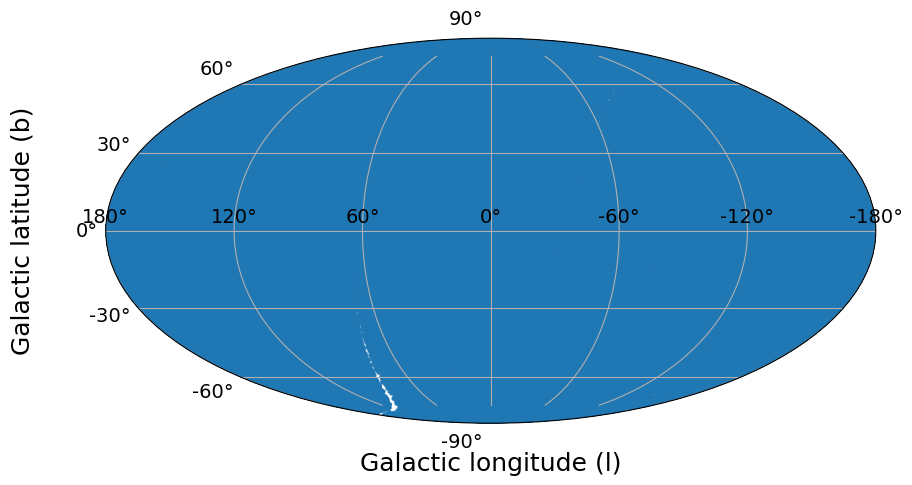

In [6]:
l = df['l'].values
b = df['b'].values

# Convertir a radianes para Mollweide
l_rad = np.radians(l - 180)  # Recentrar en 0°
b_rad = np.radians(b)

# Crear figura
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='mollweide')

# Scatter plot
ax.scatter(l_rad, b_rad, s=5, alpha=0.7)

# Grid cada 30° latitud, 60° longitud
ax.set_xticks(np.radians(np.arange(-180, 181, 60)))
ax.set_yticks(np.radians(np.arange(-90, 91, 30)))

ax.set_xticklabels(['180°', '120°', '60°', '0°', '-60°', '-120°', '-180°'])
ax.set_yticklabels(['-90°', '-60°', '-30°', '0°', '30°', '60°', '90°'])

ax.grid(True)
ax.set_xlabel('Galactic longitude (l)', labelpad=20)
ax.set_ylabel('Galactic latitude (b)', labelpad=30)
plt.savefig("figures/data_initial.png")
plt.show()

In [7]:
def silhouette_por_cluster_dataframe(
    df: pd.DataFrame,
    cluster_col: str = 'cluster',
    feature_cols: list = None
) -> pd.Series:
    """
    Calcula el coeficiente silhouette promedio por clúster.
    
    Computa la métrica de silhouette para cada muestra sobre características
    especificadas, luego agrupa por clúster para obtener el valor promedio.
    Excluye automáticamente datos etiquetados como ruido (cluster_col == -1).
    
    Args:
        df: DataFrame con datos de estrellas y etiquetas de clúster.
        cluster_col: Nombre de la columna que contiene las etiquetas de clúster.
            Default: 'cluster'.
        feature_cols: Lista de columnas a usar como características para silhouette.
            Si es None, se detectan automáticamente todas las columnas numéricas.
            Default: None.
    
    Returns:
        Series indexada por cluster_col con el silhouette promedio por clúster.
        Unidades: [-1, 1] donde 1 indica clúster perfectamente separado.
    
    Raises:
        ValueError: Si feature_cols contiene columnas que no existen en df.
    
    Example:
        >>> silhouette = silhouette_por_cluster_dataframe(
        ...     df, cluster_col='cluster', feature_cols=['x', 'y', 'z']
        ... )
    """
    # Excluir ruido
    df_valido = df[df[cluster_col] != -1].copy()

    if feature_cols is None:
        # Detectar columnas numéricas automáticamente si no se especifican
        feature_cols = df_valido.select_dtypes(include=['float64', 'int64']).columns.tolist()
        feature_cols.remove(cluster_col)

    X = df_valido[feature_cols].values
    labels = df_valido[cluster_col].values

    # Calcular silhouette por muestra
    sil_values = silhouette_samples(X, labels)

    df_valido['silhouette'] = sil_values

    # Agrupar por clúster y calcular promedio
    silhouette_mean = df_valido.groupby(cluster_col)['silhouette'].mean()

    return silhouette_mean

def r2_por_cluster_dataframe(
    df: pd.DataFrame,
    cluster_col: str = 'cluster',
    x_col: str = 'bp_rp',
    y_col: str = 'phot_g_mean_mag',
    calcular_rmse: bool = True,
    calcular_residual_std: bool = True
) -> pd.DataFrame:
    """
    Ajusta regresión lineal por clúster y calcula métricas de bondad de ajuste.
    
    Para cada clúster (excluyendo ruido), realiza una regresión lineal de y_col
    sobre x_col y computa R², RMSE y desviación estándar de residuos.
    
    Args:
        df: DataFrame con datos de estrellas.
        cluster_col: Nombre de la columna de clústers. Default: 'cluster'.
        x_col: Nombre de la variable independiente. Default: 'bp_rp'.
        y_col: Nombre de la variable dependiente. Default: 'phot_g_mean_mag'.
        calcular_rmse: Si True, calcula RMSE (Mean Squared Error). Default: True.
        calcular_residual_std: Si True, calcula desviación estándar de residuos.
            Default: True.
    
    Returns:
        DataFrame con columnas [cluster_col, 'r2', 'rmse_{y}_vs_{x}', 
        'std_residuos_{y}_vs_{x}']. Una fila por clúster con al menos 2 
        observaciones.
    
    Raises:
        ValueError: Si x_col o y_col no existen en df.
    
    Example:
        >>> r2_results = r2_por_cluster_dataframe(
        ...     df, cluster_col='cluster', x_col='bp_rp', y_col='phot_g_mean_mag'
        ... )
    """
    df_valido = df[df[cluster_col] != -1].copy()
    resultados = []

    for cluster, grupo in df_valido.groupby(cluster_col):
        if len(grupo) < 2:
            continue

        X = grupo[[x_col]].values
        y = grupo[y_col].values

        modelo = LinearRegression().fit(X, y)
        y_pred = modelo.predict(X)
        r2 = r2_score(y, y_pred)**2 # modificado

        resultado_cluster = {
            cluster_col: cluster,
            'r2': r2
        }

        if calcular_rmse:
            rmse = mean_squared_error(y, y_pred)
            resultado_cluster[f'rmse_{y_col}_vs_{x_col}'] = rmse

        if calcular_residual_std:
            residuos = y - y_pred
            std_residuos = np.std(residuos)
            resultado_cluster[f'std_residuos_{y_col}_vs_{x_col}'] = std_residuos

        resultados.append(resultado_cluster)

    return pd.DataFrame(resultados)

def dispersion_por_cluster(
    df: pd.DataFrame,
    cluster_col: str = 'cluster',
    variable: str = 'phot_g_mean_mag',
    metodo: str = 'std'
) -> pd.DataFrame:
    """
    Calcula la dispersión (esparcimiento) de una variable por clúster.
    
    Agrupa los datos por clúster y computa diferentes medidas de dispersión:
    desviación estándar, varianza, o rango intercuartil (IQR).
    
    Args:
        df: DataFrame con datos de estrellas.
        cluster_col: Nombre de la columna de clústers. Default: 'cluster'.
        variable: Nombre de la variable a medir dispersión. 
            Default: 'phot_g_mean_mag'.
        metodo: Método de cálculo. Opciones: 'std', 'var', 'iqr'.
            Default: 'std'.
    
    Returns:
        DataFrame con columnas [cluster_col, f'dispersion_{variable}_{metodo}'].
        Una fila por clúster (excluyendo ruido).
    
    Raises:
        ValueError: Si metodo no está en ['std', 'var', 'iqr'].
        ValueError: Si variable no existe en df.
    
    Example:
        >>> dispersion = dispersion_por_cluster(
        ...     df, cluster_col='cluster', variable='phot_g_mean_mag', metodo='std'
        ... )
    """
    df_valido = df[df[cluster_col] != -1].copy()

    if metodo == 'std':
        dispersion = df_valido.groupby(cluster_col)[variable].std().reset_index()
        dispersion = dispersion.rename(columns={variable: f'dispersion_{variable}_std'})
    elif metodo == 'var':
        dispersion = df_valido.groupby(cluster_col)[variable].var().reset_index()
        dispersion = dispersion.rename(columns={variable: f'dispersion_{variable}_var'})
    elif metodo == 'iqr':
        dispersion = df_valido.groupby(cluster_col).agg(
            Q3=(variable, lambda x: np.percentile(x, 75)),
            Q1=(variable, lambda x: np.percentile(x, 25))
        )
        dispersion['iqr'] = dispersion['Q3'] - dispersion['Q1']
        dispersion = dispersion.reset_index()[[cluster_col, 'iqr']]
        dispersion = dispersion.rename(columns={'iqr': f'dispersion_{variable}_iqr'})
    else:
        raise ValueError("Método no soportado. Usa 'std', 'var' o 'iqr'.")

    return dispersion

def escalar_columnas(
    df: pd.DataFrame,
    columnas: list,
    nuevo_min: float = 0,
    nuevo_max: float = 5
) -> pd.DataFrame:
    """
    Escala columnas numéricas a un rango especificado usando normalización min-max.
    
    Aplica transformación lineal para mapear el rango [min_col, max_col] al rango
    [nuevo_min, nuevo_max]. Si una columna no tiene variación, se asigna nuevo_min.
    
    Args:
        df: DataFrame con datos.
        columnas: Lista de nombres de columnas a escalar.
        nuevo_min: Valor mínimo del rango objetivo. Default: 0.
        nuevo_max: Valor máximo del rango objetivo. Default: 5.
    
    Returns:
        DataFrame con las columnas originales + nuevas columnas escaladas 
        con sufijo '_esc'.
        
    Example:
        >>> scaled_df = escalar_columnas(
        ...     df, columnas=['r2', 'silhouette'], nuevo_min=0, nuevo_max=5
        ... )
        >>> scaled_df[['r2_esc', 'silhouette_esc']].head()
    """
    df_escalado = df.copy()
    for col in columnas:
        min_val = df[col].min()
        max_val = df[col].max()
        if min_val == max_val:
            df_escalado[col + '_esc'] = nuevo_min  # o 0 si no hay variación
        else:
            df_escalado[col + '_esc'] = nuevo_min + (df[col] - min_val) * (nuevo_max - nuevo_min) / (max_val - min_val)
    return df_escalado

def filtrar_clusters_destacados(
    df: pd.DataFrame,
    columnas_originales: list,
    columnas_escaladas: list,
    percentil: float = 0.9
) -> pd.DataFrame:
    """
    Filtra clústers que cumplen criterios de calidad mínima y excelencia.
    
    Retiene solo clústers donde todas las métricas originales sean positivas
    y todas las métricas escaladas estén en el top percentil especificado.
    Útil para identificar clústers "destacados" o de alta calidad.
    
    Args:
        df: DataFrame con métricas calculadas por clúster.
        columnas_originales: Lista de columnas de métricas originales.
            Se retienen filas donde TODAS > 0.
        columnas_escaladas: Lista de columnas de métricas escaladas.
            Se retienen filas donde TODAS >= percentil p.
        percentil: Valor de percentil para filtrar (0-1).
            Default: 0.9 (top 10%).
    
    Returns:
        DataFrame filtrado con clústers que cumplen ambos criterios.
        Si ningún clúster califica, retorna DataFrame vacío.
    
    Example:
        >>> top_clusters = filtrar_clusters_destacados(
        ...     silhouette_por_cluster,
        ...     columnas_originales=['silhouette', 'r2'],
        ...     columnas_escaladas=['silhouette_esc', 'r2_esc'],
        ...     percentil=0.85
        ... )
    """
    df_filtrado = df.copy()

    # Paso 1: Filtrar donde todas las métricas originales sean > 0
    for col in columnas_originales:
        df_filtrado = df_filtrado[df_filtrado[col] > 0]

    # Paso 2: Filtrar donde todas las métricas escaladas estén en el top percentil
    for col in columnas_escaladas:
        umbral = df[col].quantile(percentil)
        df_filtrado = df_filtrado[df_filtrado[col] >= umbral]

    return df_filtrado

def calculate_percentile_metrics(
    df: pd.DataFrame,
    cluster_col: str = 'cluster',
    variable: str = 'parallax',
    percentiles: tuple = (5, 100)
) -> pd.DataFrame:
    """
    Calcula mediana y ancho (diferencia entre percentiles) para una variable por clúster.
    
    Args:
        df: DataFrame con datos de estrellas.
        cluster_col: Nombre de la columna de clústers.
        variable: Nombre de la variable a analizar (ej. 'parallax', 'distance_pc').
        percentiles: Tupla (p_min, p_max) para calcular el ancho. Default: (5, 100).
    
    Returns:
        DataFrame with columns: cluster, {variable}_median, {variable}_p{p_min}, 
        {variable}_p{p_max}, {variable}_width_p{p_min}_p{p_max}
    """
    df_valido = df[df[cluster_col] != -1].copy()
    
    p_min, p_max = percentiles
    
    metrics = df_valido.groupby(cluster_col)[variable].agg(
        **{
            f'{variable}_median': 'median',
            f'{variable}_p{p_min}': lambda x: np.percentile(x, p_min),
            f'{variable}_p{p_max}': lambda x: np.percentile(x, p_max)
        }
    ).reset_index()
    
    # Calcular ancho (p_max - p_min)
    metrics[f'{variable}_width_p{p_min}_p{p_max}'] = (
        metrics[f'{variable}_p{p_max}'] - metrics[f'{variable}_p{p_min}']
    )
    
    return metrics

def calculate_cluster_radius(
    df: pd.DataFrame,
    cluster_col: str = 'cluster',
    coord_cols: list = None,
    metrics: list = None
) -> pd.DataFrame:
    """
    Calcula métricas de radio y dispersión espacial para cada clúster.
    
    Utiliza un sistema de coordenadas cartesianas x, y, z (en parsecs)
    derivadas de coordenadas esféricas ICRS para capturar la geometría
    real de los clústers estelares.
    
    Args:
        df: DataFrame con datos de estrellas.
        cluster_col: Nombre de la columna de clústers.
        coord_cols: Lista de columnas de coordenadas [x, y, z].
                   Default: ['x_pc', 'y_pc', 'z_pc'].
        metrics: Lista de métricas a calcular.
                Default: ['mean', 'median', 'std', 'rms', 'effective_radius'].
    
    Returns:
        DataFrame con columnas: cluster, radio_mean, radio_median,
        radio_std, radio_rms, radius_effective.
        
    Raises:
        ValueError: Si las columnas de coordenadas no existen.
    """
    if coord_cols is None:
        coord_cols = ['x_pc', 'y_pc', 'z_pc']
    
    if metrics is None:
        metrics = ['mean', 'median', 'std', 'rms', 'effective_radius']
    
    # Validar que existan las columnas
    missing_cols = [col for col in coord_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Columnas no encontradas: {missing_cols}")
    
    df_valido = df[df[cluster_col] != -1].copy()
    resultados = []
    
    for cluster_id, grupo in df_valido.groupby(cluster_col):
        fila_resultado = {cluster_col: cluster_id}
        
        # Calcular centroide del clúster
        centroide = grupo[coord_cols].mean().values
        
        # Calcular distancias euclideas desde el centroide
        distancias = np.linalg.norm(
            grupo[coord_cols].values - centroide,
            axis=1
        )
        
        # Calcular métricas solicitadas
        if 'mean' in metrics:
            fila_resultado['radio_mean'] = np.mean(distancias)
        
        if 'median' in metrics:
            fila_resultado['radio_median'] = np.median(distancias)
        
        if 'std' in metrics:
            fila_resultado['radio_std'] = np.std(distancias)
        
        if 'rms' in metrics:
            # RMS considerando también la distancia desde el centro galáctico
            distancias_rms = np.sqrt(grupo[coord_cols].pow(2).sum(axis=1))
            fila_resultado['radio_rms'] = np.mean(distancias_rms)
        
        if 'effective_radius' in metrics:
            # Radio que encierra el 50% de las estrellas del clúster
            fila_resultado['radius_effective'] = np.percentile(distancias, 50)
        
        resultados.append(fila_resultado)
    
    return pd.DataFrame(resultados)

In [8]:
nueva_numeracion = np.arange(0,len(df['division'].unique()))
d_nueva_numeracion = dict(zip(df['division'].unique(),nueva_numeracion))
df['numeracion'] = df['division'].map(d_nueva_numeracion)
df['cluster'] = (df['grupo'].astype(str) + df['numeracion'].astype(str)).astype(int)

In [9]:
dff = df[df['cluster']>0].copy()

In [10]:
dff['abs'] = dff['phot_g_mean_mag'] - 5*np.log10(1000/dff['parallax'])+5

In [11]:
dff = dff[dff['cluster']>0]

In [13]:
feature_cols = ['pmra_corrected_norm', 'pmdec_corrected_norm','parallax_corrected_norm']
silhouette_por_cluster = silhouette_por_cluster_dataframe(dff, cluster_col='cluster', feature_cols=feature_cols).reset_index()
silhouette_por_distancia = silhouette_por_cluster_dataframe(dff, cluster_col='cluster', feature_cols=['x_pc','y_pc','z_pc']).reset_index()
silhouette_por_movimientos = silhouette_por_cluster_dataframe(dff, cluster_col='cluster', feature_cols=['pmra_corrected_norm','pmdec_corrected_norm']).reset_index()
r2_clusters = r2_por_cluster_dataframe(dff.dropna(subset=['phot_g_mean_mag','bp_rp']), cluster_col='cluster', x_col='bp_rp', y_col='phot_g_mean_mag',calcular_residual_std = False)
dispersion_magnitud = dispersion_por_cluster(dff, variable='phot_g_mean_mag', metodo='std')
probabilidad_cluster = dff.groupby(['cluster']).agg({'probabilidad':'median','source_id':'count','fidelity_v2':'mean'}).reset_index()
parallax_metrics = calculate_percentile_metrics(
    dff, cluster_col='cluster', variable='parallax', percentiles=(5, 95)
)

distance_metrics = calculate_percentile_metrics(
    dff, cluster_col='cluster', variable='distance_pc', percentiles=(5, 95)
)
radius_metrics = calculate_cluster_radius(
    dff,
    cluster_col='cluster',
    coord_cols=['x_pc', 'y_pc', 'z_pc'],
    metrics=['mean', 'median', 'std', 'effective_radius']
)
# Fusionar todas las métricas
silhouette_por_cluster = (
    silhouette_por_cluster
    .merge(probabilidad_cluster, how='inner', on=['cluster'])
    .merge(
        silhouette_por_distancia.rename(
            columns={'silhouette': 'silhouette_distancia'}
        ),
        how='inner',
        on=['cluster']
    )
    .merge(
        silhouette_por_movimientos.rename(
            columns={'silhouette': 'silhouette_movimientos'}
        ),
        how='inner',
        on=['cluster']
    )
    .merge(r2_clusters, how='inner', on='cluster')
    .merge(dispersion_magnitud, how='inner', on='cluster')
    .merge(parallax_metrics, how='inner', on='cluster') 
    .merge(distance_metrics, how='inner', on='cluster')  
    .merge(radius_metrics, how='inner', on=['cluster'])
)
# Columnas que vas a escalar
columnas_a_escalar = [
    'silhouette',
    'silhouette_distancia',
    'silhouette_movimientos',
    'probabilidad',
    'r2',
    'rmse_phot_g_mean_mag_vs_bp_rp',
    # 'parallax_width_p5_p100',
    # 'distance_pc_width_p5_p100',
    # 'radius_effective'
]

# Escalamos al rango 0-5
silhouette_por_cluster = escalar_columnas(silhouette_por_cluster, columnas=columnas_a_escalar)

# Calculamos métrica global como suma de las columnas escaladas
columnas_escaladas = [col + '_esc' for col in columnas_a_escalar]
silhouette_por_cluster = silhouette_por_cluster[silhouette_por_cluster['silhouette_distancia']>0]

In [14]:
silhouette_por_cluster['metrica'] = silhouette_por_cluster[['silhouette_distancia', 'probabilidad', 'r2']].product(axis=1)

In [15]:
# listado de clusters generados
clusters = np.sort(dff['cluster'].unique())
# Crear un colormap con tantos colores como clusters
colormap = cm.get_cmap('Set1', len(clusters))  # o 'tab20', 'nipy_spectral', etc.

# Crear un diccionario de colores para cada cluster
color_dict = {cluster: colormap(i) for i, cluster in enumerate(clusters)}

# Asignar el color correspondiente a cada fila
dff['color'] = dff['cluster'].map(color_dict)
dff.to_csv("C:\\Users\\nicob\\One Drive Uniandes\\OneDrive - Universidad de los Andes\\Doctorado\\proyecto\\clusterization_project\\data\\datos_resultados_modularizado\\datos_processed_wo_fidelity.csv", index=False)

C:\Users\nicob\AppData\Local\Temp\ipykernel_3000\882968491.py:4: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.



In [16]:
# silhouette_por_cluster[(silhouette_por_cluster['silhouette_distancia']>0.)\
                        # &(silhouette_por_cluster['probabilidad']>0.)\
                        # &(silhouette_por_cluster['silhouette_movimientos']>0)]\
variables_orden = ['silhouette_distancia'
                   ,'silhouette'
                   ,'silhouette_movimientos'
                   ,'radius_effective'
                   ,'probabilidad'
                   ,'distance_pc_width_p5_p95'
                   ,'radio_median'
                   ,'metrica']
variable_cluster = ["cluster","source_id"]
silhouette_por_cluster[(silhouette_por_cluster['silhouette_distancia'] > 0)&(silhouette_por_cluster['silhouette'] > 0)&(silhouette_por_cluster['silhouette_movimientos'] > 0) & (silhouette_por_cluster['fidelity_v2'] > 0.3)].sort_values(by=variables_orden, ascending=[0,0,0,0,0,0,0,0]).head(20)[variable_cluster + variables_orden]

,cluster,source_id,silhouette_distancia,silhouette,silhouette_movimientos,radius_effective,probabilidad,distance_pc_width_p5_p95,radio_median,metrica
0,7,264,0.755818,0.475165,0.666905,12.179175,0.7875,21.850262,12.179175,0.312642
1,8,454,0.734793,0.504220,0.283983,6.000418,0.7900,27.930484,6.000418,0.383232
22,116,86,0.137033,0.093461,0.164887,13.391549,0.0500,28.545801,13.391549,0.000193


In [17]:
radius_metrics = calculate_cluster_radius(
    dff,
    cluster_col='cluster',
    coord_cols=['x_pc', 'y_pc', 'z_pc'],
    metrics=['mean', 'median', 'std', 'effective_radius']
)
radius_metrics

,cluster,radio_mean,radio_median,radio_std,radius_effective
0,7,15.313600,12.179175,10.208930,12.179175
1,8,7.798008,6.000418,6.408283,6.000418
2,10,52.526928,38.158063,32.001338,38.158063
3,13,15.109598,14.926963,5.677680,14.926963
4,15,8.827132,8.043700,4.812875,8.043700
5,16,16.941628,17.133843,5.887883,17.133843
6,17,36.107507,34.858496,8.744229,34.858496
7,18,15.707507,15.795336,6.444548,15.795336
8,20,6.197492,5.593950,3.176364,5.593950
9,28,8.177974,7.826310,3.709289,7.826310


In [18]:
variables_orden = ['silhouette'
                   ,'radius_effective'
                   ,'probabilidad'
                   ,'radius_effective'
                   ]
variable_cluster = ["cluster","source_id"]
silhouette_por_cluster[(silhouette_por_cluster['silhouette_distancia'] > 0)&(silhouette_por_cluster['silhouette'] > 0)&(silhouette_por_cluster['silhouette_movimientos'] > 0) & (silhouette_por_cluster['fidelity_v2'] > 0.3)].sort_values(by='source_id', ascending=[0]).head(20)[variable_cluster + variables_orden]

,cluster,source_id,silhouette,radius_effective,probabilidad,radius_effective
1,8,454,0.504220,6.000418,0.7900,6.000418
0,7,264,0.475165,12.179175,0.7875,12.179175
22,116,86,0.093461,13.391549,0.0500,13.391549


In [19]:
# # silhouette_por_cluster[(silhouette_por_cluster['silhouette_distancia']>0.)\
#                         # &(silhouette_por_cluster['probabilidad']>0.)\
#                         # &(silhouette_por_cluster['silhouette_movimientos']>0)]\
# variables_orden = ['metrica'
#                    ,'silhouette_distancia'
#                    ,'silhouette'
#                    ,'silhouette_movimientos'
#                    ,'distance_pc_width_p5_p95'
#                    ,'probabilidad'
#                    ,'radius_effective'
#                    ,'radio_median']
# variable_cluster = ["cluster","source_id"]
# silhouette_por_cluster.sort_values(by=variables_orden, ascending=[0,0,0,0,0,0,0,0]).head(20)[variable_cluster + variables_orden]

8


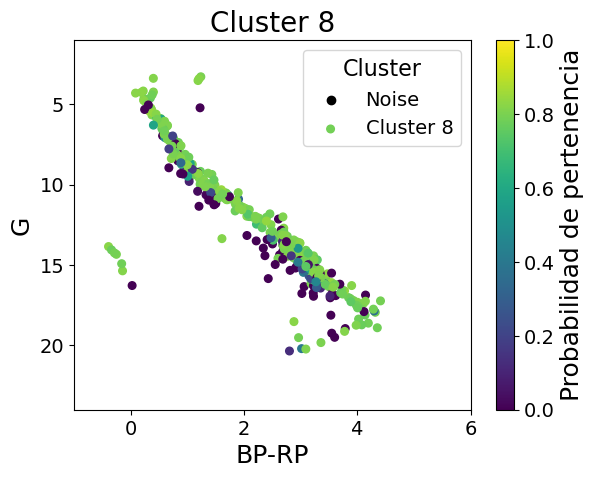

7


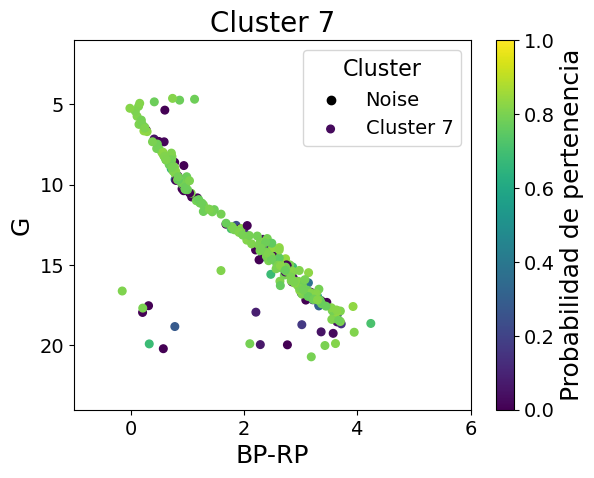

116


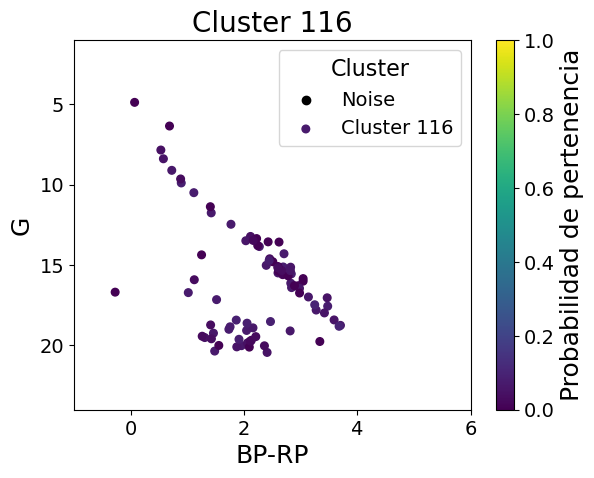

18


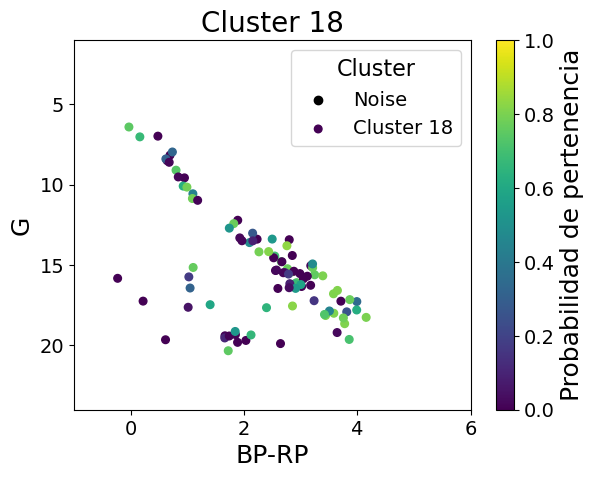

In [33]:
for cluster in silhouette_por_cluster[silhouette_por_cluster["fidelity_v2"]>0.5].sort_values(by=variables_orden, ascending=[0,0,0,0]).head(15)['cluster'].values:
    print(cluster)
    subset = dff[dff['cluster'] == cluster]

    # Dibujar ruido en negro con alfa fijo
    noise = dff[dff['cluster'] < 0]
    plt.scatter(noise['bp_rp'], noise['phot_g_mean_mag'], color='k', label='Noise')

    # Obtener la probabilidad y normalizarla si es necesario
    prob = subset['probabilidad']
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.viridis

    # Crear scatter plot con color en función de la probabilidad
    sc = plt.scatter(subset['bp_rp'], subset['phot_g_mean_mag'],
                     c=prob,
                     cmap=cmap,
                     norm=norm,
                     s=30,
                     label=f'Cluster {cluster}')

    plt.xlabel('BP-RP')
    plt.ylabel('G')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.xlim(-1,6)
    plt.ylim(1,24)
    plt.gca().invert_yaxis()

    # Agregar barra de color
    cbar = plt.colorbar(sc)
    cbar.set_label('Probabilidad de pertenencia')

    # plt.savefig(f"ruta_imagenes_evolucion/diagramas_cm/diagrama_cluster_{cluster}.png")
    plt.show()

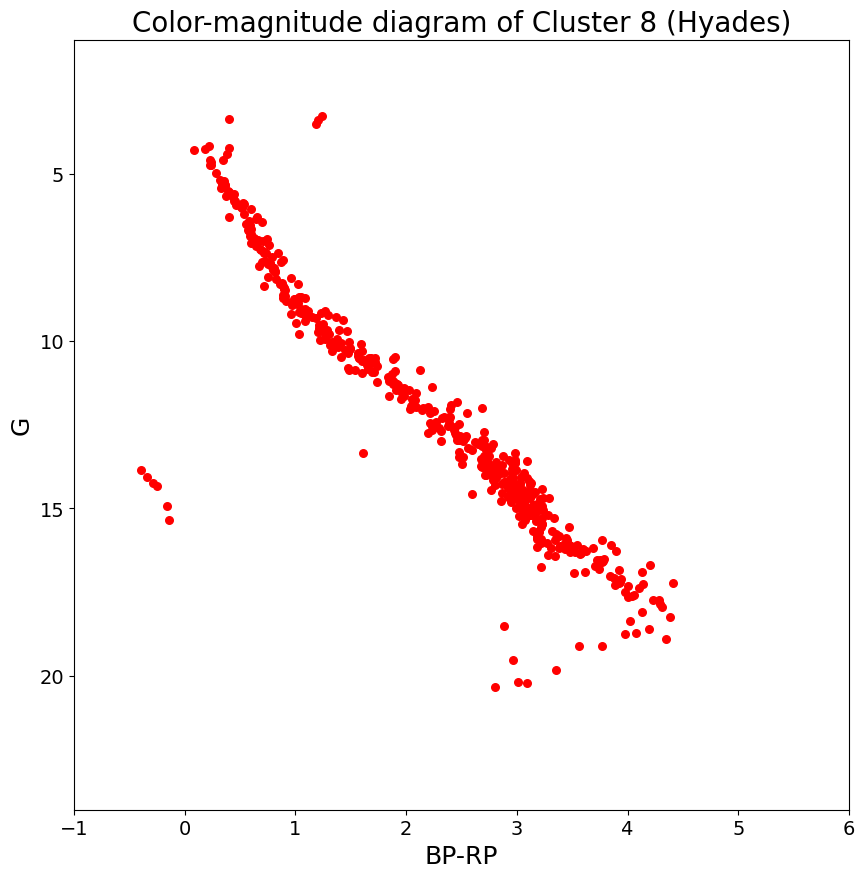

In [ ]:
df_hyades = dff[dff['cluster'] == 8]
plt.figure(figsize=(10, 10))
plt.scatter(df_hyades['bp_rp'], df_hyades['phot_g_mean_mag'], c='red', s=30)
plt.xlabel('BP-RP')
plt.ylabel('G')
plt.title('Color-magnitude diagram of Cluster 8 (Hyades)')
plt.xlim(-1,6)
plt.ylim(1,24)
plt.gca().invert_yaxis()
plt.savefig(f"figures/diagrama_cm_hyades.png")
plt.show()

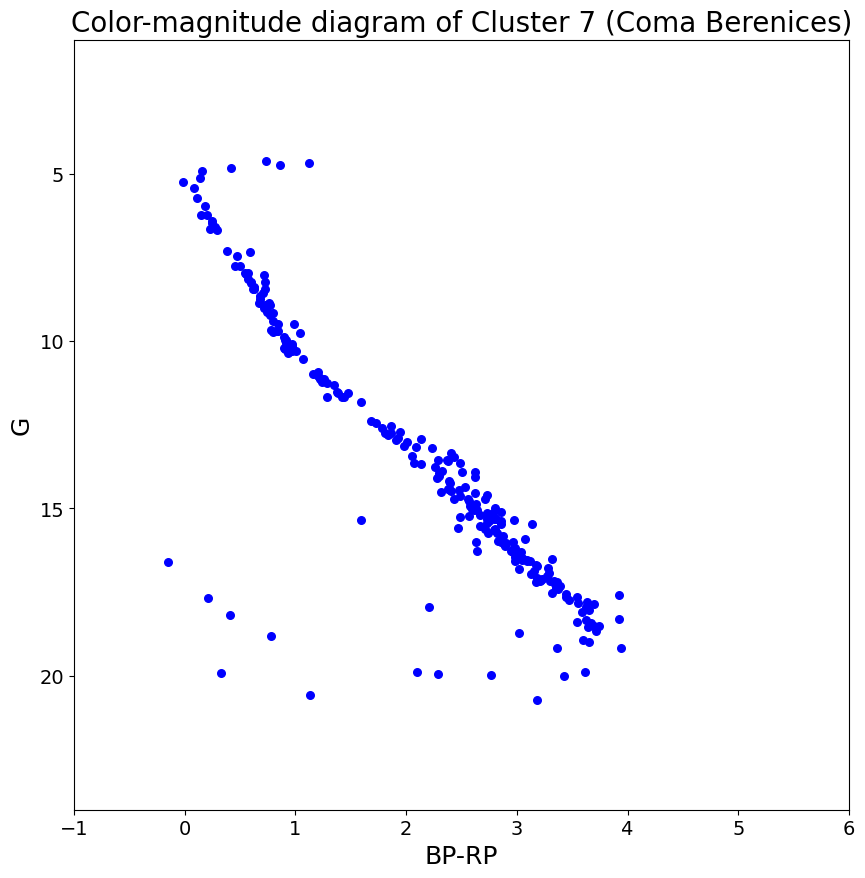

In [ ]:
df_coma = dff[dff['cluster'] == 7]
plt.figure(figsize=(10, 10))
plt.scatter(df_coma['bp_rp'], df_coma['phot_g_mean_mag'], c='blue', s=30)
plt.xlabel('BP-RP')
plt.ylabel('G')
plt.title('Color-magnitude diagram of Cluster 7 (Coma Berenices)')
plt.xlim(-1,6)
plt.ylim(1,24)
plt.gca().invert_yaxis()
plt.savefig(f"figures/diagrama_cm_coma.png")
plt.show()

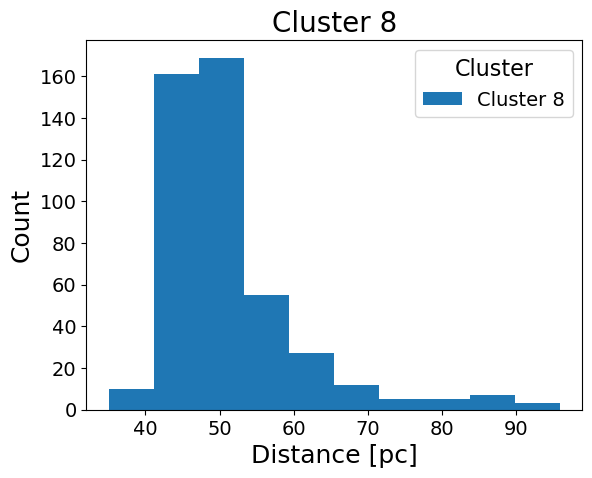

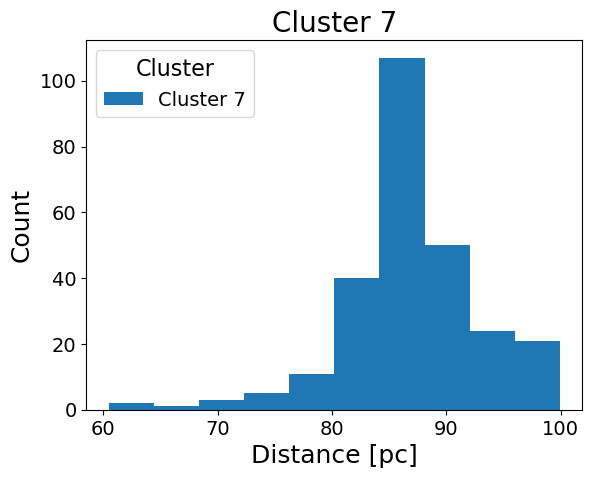

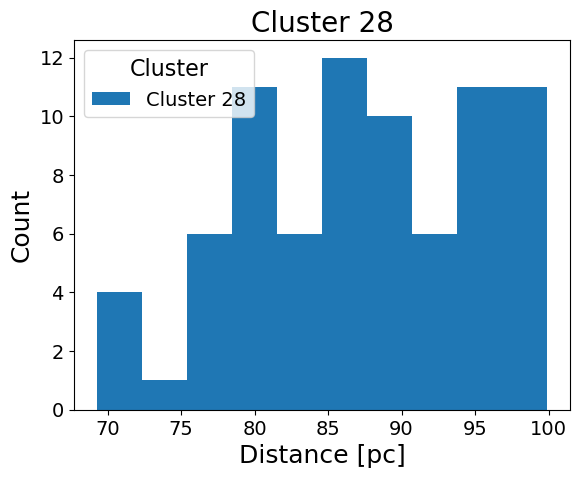

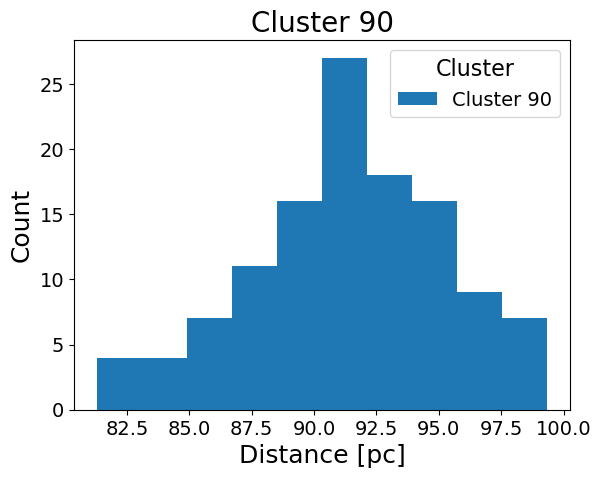

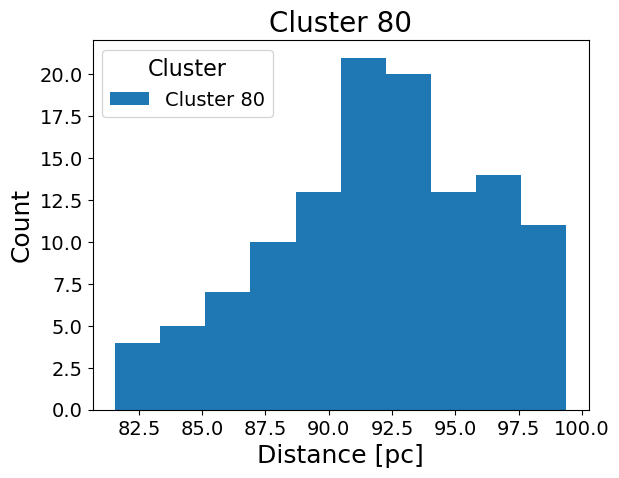

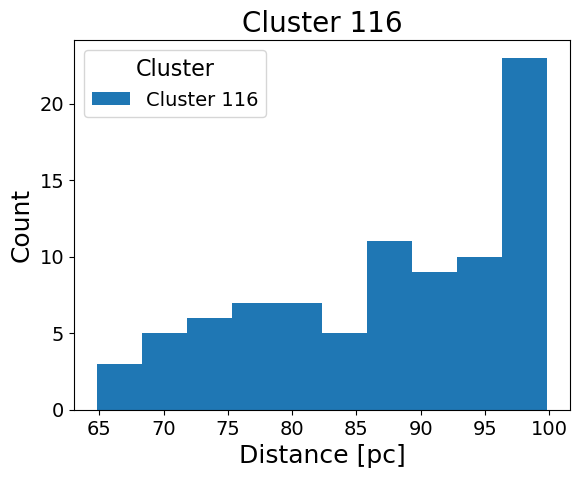

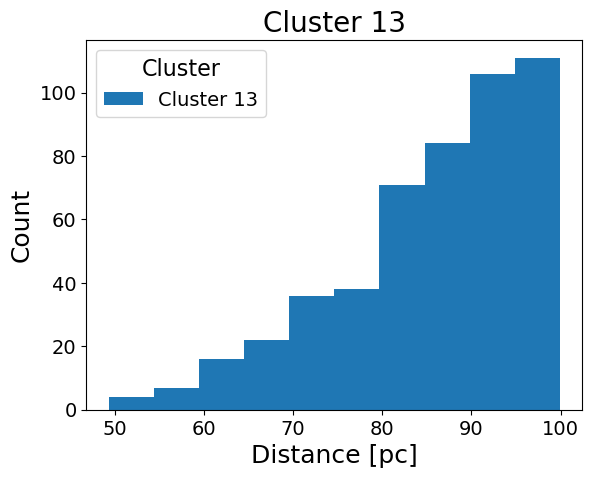

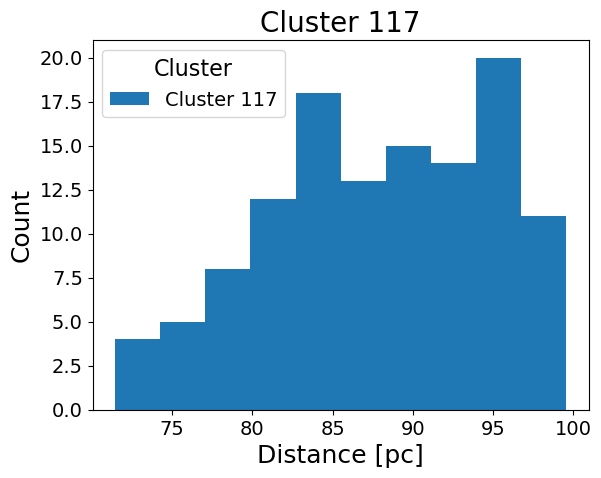

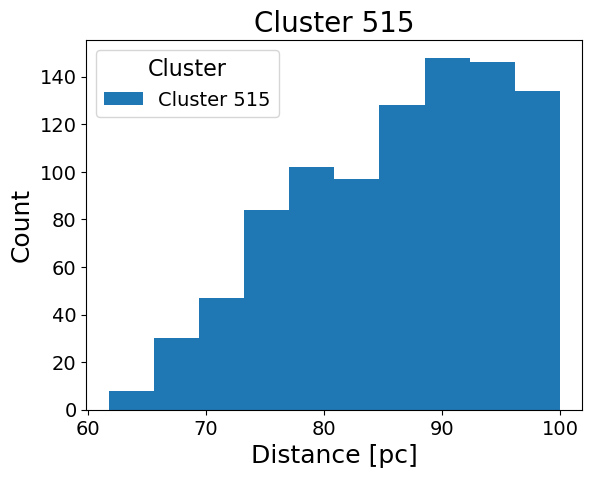

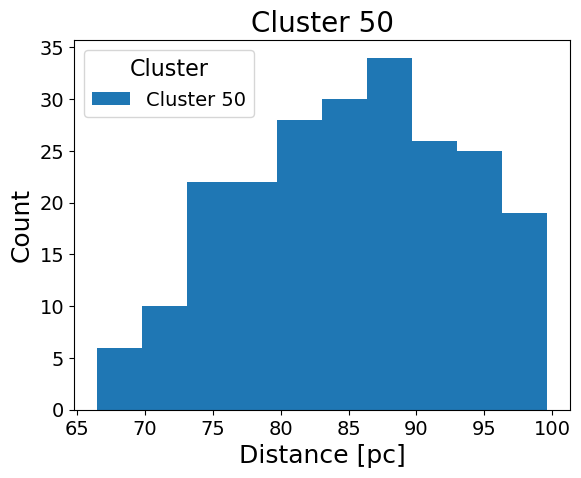

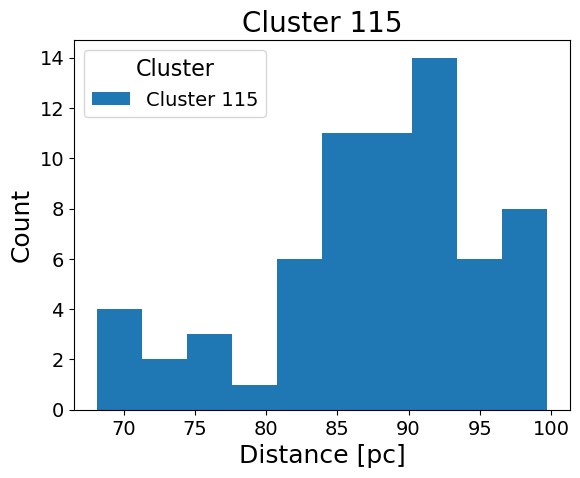

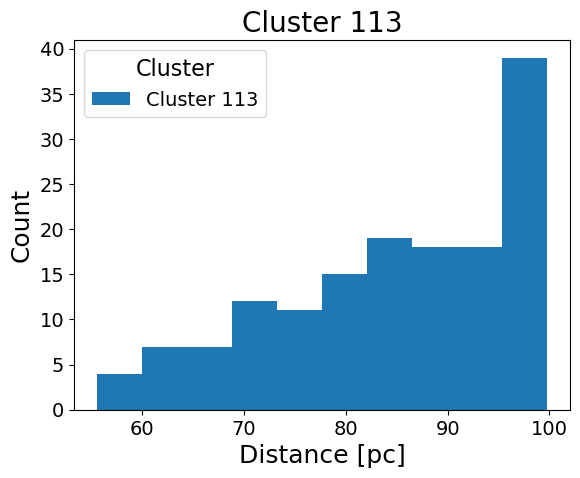

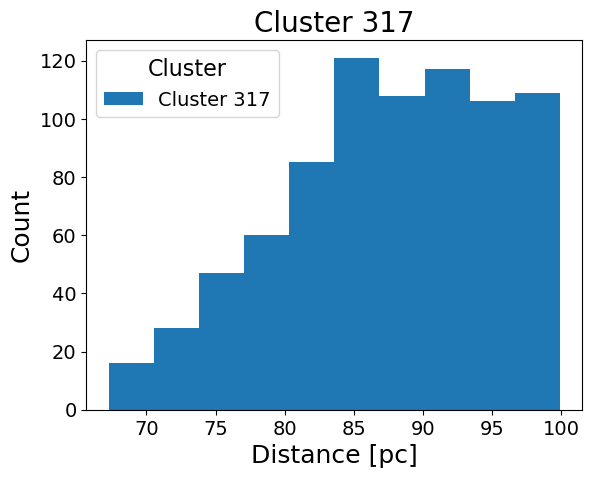

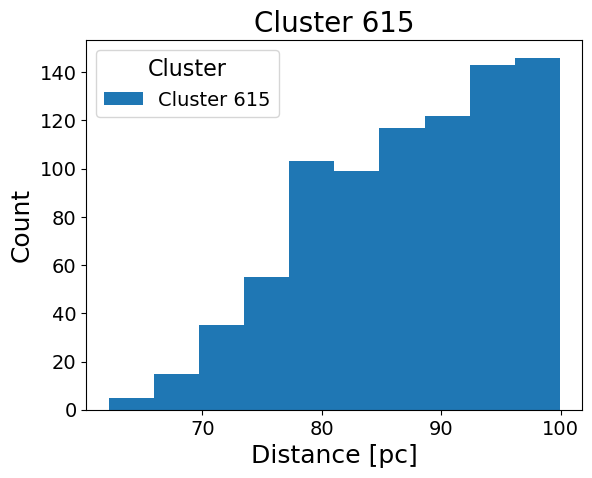

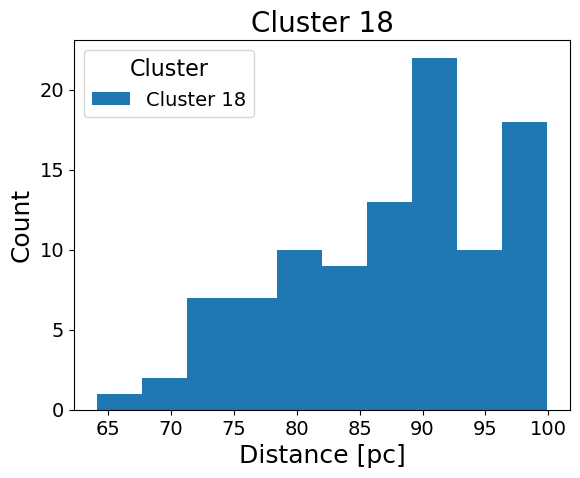

In [32]:
for cluster in silhouette_por_cluster.sort_values(by=variables_orden, ascending=[0,0,0,0]).head(15)['cluster'].values:
    subset = dff[dff['cluster'] == cluster]

    # Obtener la probabilidad y normalizarla si es necesario
    prob = subset['fidelity_v2']
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.viridis

    # Crear scatter plot con color en función de la probabilidad
    sc = plt.hist(1000/subset['parallax'],
                     label=f'Cluster {cluster}')

    plt.xlabel('Distance [pc]')
    plt.ylabel('Count')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')

    plt.savefig(f"figures/parallax_histogram_{cluster}.png")
    plt.show()

In [ ]:
for cluster in silhouette_por_cluster[(silhouette_por_cluster['silhouette_distancia'] > 0)&(silhouette_por_cluster['silhouette'] > 0)&(silhouette_por_cluster['silhouette_movimientos'] > 0) & (silhouette_por_cluster['fidelity_v2'] > 0.3)].sort_values(by=variables_orden, ascending=[0,0,0,0,0,0,0,0]).head(15)['cluster'].values:
    subset = dff[dff['cluster'] == cluster]

    # Dibujar ruido en negro con alfa fijo
    noise = dff[dff['cluster'] < 0]
    plt.scatter(noise['bp_rp'], noise['phot_g_mean_mag'], color='k', label='Noise')

    # Obtener la probabilidad y normalizarla si es necesario
    prob = subset['fidelity_v2']
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.cool

    # Crear scatter plot con color en función de la probabilidad
    sc = plt.scatter(subset['bp_rp'], subset['phot_g_mean_mag'],
                     c=prob,
                     cmap=cmap,
                     norm=norm,
                     s=30,
                     label=f'Cluster {cluster}')

    plt.xlabel('BP-RP')
    plt.ylabel('G')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.xlim(-1,6)
    plt.ylim(1,24)
    plt.gca().invert_yaxis()

    # Agregar barra de color
    cbar = plt.colorbar(sc)
    cbar.set_label('Fidelity')

    # plt.savefig(f"ruta_imagenes_evolucion/diagramas_cm/diagrama_cluster_{cluster}.png")
    plt.show()

NameError: name 'silhouette_por_cluster' is not defined

In [ ]:
# graficar en latitud y longitud galactiva

In [ ]:
# Crear figura Mollweide
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='mollweide')

# Graficar por cada cluster
clusters = silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(5)['cluster'].values
colors = plt.cm.tab10(np.linspace(0, 1, len(silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(5)['cluster'].values)))  # Paleta de colores
  # Paleta de colores

for cluster, color in zip(silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(5)['cluster'].values, colors):
    subset = dff[dff['cluster'] == cluster].reset_index(drop=True)
    ax.scatter(subset['l_rad'], subset['b_rad'], s=20, alpha=1, label=f'Cluster {cluster}', color=color)

# Etiquetas y rejilla
ax.set_xticks(np.radians(np.arange(-180, 181, 60)))
ax.set_yticks(np.radians(np.arange(-90, 91, 30)))
ax.set_xticklabels(['180°', '120°', '60°', '0°', '-60°', '-120°', '-180°'])
ax.set_yticklabels(['-90°', '-60°', '-30°', '0°', '30°', '60°', '90°'])
ax.grid(True)
ax.set_xlabel('Longitud galáctica (l)', labelpad=20)
ax.set_ylabel('Latitud galáctica (b)', labelpad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.show()

In [ ]:
# Crear figura Mollweide
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='mollweide')

# Graficar por cada cluster
clusters = silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(5)['cluster'].values
colors = plt.cm.tab10(np.linspace(0, 1, len(silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(5)['cluster'].values)))  # Paleta de colores
  # Paleta de colores

for cluster, color in zip(silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(3)['cluster'].values, colors):
    subset = dff[dff['cluster'] == cluster].reset_index(drop=True)
    ax.scatter(subset['l_rad'], subset['b_rad'], s=20, alpha=1, label=f'Cluster {cluster}', color=color)

# Etiquetas y rejilla
ax.set_xticks(np.radians(np.arange(-180, 181, 60)))
ax.set_yticks(np.radians(np.arange(-90, 91, 30)))
ax.set_xticklabels(['180°', '120°', '60°', '0°', '-60°', '-120°', '-180°'])
ax.set_yticklabels(['-90°', '-60°', '-30°', '0°', '30°', '60°', '90°'])
ax.grid(True)
ax.set_xlabel('Longitud galáctica (l)', labelpad=20)
ax.set_ylabel('Latitud galáctica (b)', labelpad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.show()

In [ ]:
dic_color = dict(zip(silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(3)['cluster'].values,["red","blue","m"]))
for cluster in silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(3)['cluster'].values:
    subset = dff[dff['cluster'] == cluster]

    # Obtener la probabilidad y normalizarla si es necesario
    prob = subset['probabilidad']
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.viridis

    # Crear scatter plot con color en función de la probabilidad
    sc = plt.scatter(subset['bp_rp'], subset['abs'],
                     c=dic_color[cluster],
                     norm=norm,
                     s=30,
                     label=f'Cluster {cluster}')

    plt.xlabel('BP-RP')
    plt.ylabel(r'$M_G$')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.gca().invert_yaxis()
plt.show()

In [ ]:
dic_color = dict(zip(silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(3)['cluster'].values,["red","blue","m"]))
for cluster in silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(3)['cluster'].values:
    subset = dff[dff['cluster'] == cluster]

    # Obtener la probabilidad y normalizarla si es necesario
    prob = subset['probabilidad']
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.viridis

    # Crear scatter plot con color en función de la probabilidad
    sc = plt.scatter(subset['bp_rp'], subset['abs'],
                     c=dic_color[cluster],
                     norm=norm,
                     s=30,
                     label=f'Cluster {cluster}')

    plt.xlabel('BP-RP')
    plt.ylabel(r'$M_G$')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.gca().invert_yaxis()
plt.show()

In [ ]:
df_analize = dff[dff['cluster'].isin([8,7,2])]

In [ ]:
# plt.hist(dff[dff['cluster'].isin([2,7,8])]['fidelity_v2'], bins=30, color ='green', density=True)
for i in [13]:
    plt.hist(dff[dff['cluster']==i]['fidelity_v2'], bins=30, alpha=0.5, label=f"Cluster {i}")
    plt.legend()
    plt.show()

In [ ]:
# plt.hist(dff[dff['cluster'].isin([2,7,8])]['fidelity_v2'], bins=30, color ='green', density=True)
for i in silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(15)['cluster'].values:
    plt.hist(dff[dff['cluster']==i]['fidelity_v2'], bins=30, alpha=0.5, label=f"Cluster {i}")
    plt.legend()
    plt.show()

In [ ]:
df_filter = dff[dff['cluster']==cluster]
combinations = [['x_pc', 'y_pc'],['x_pc', 'z_pc'],['y_pc', 'z_pc']]
for cluster in [8,7,2]:
    for comb in combinations:
        plt.figure()
        plt.scatter(df_filter[comb[0]], df_filter[comb[1]], c=df_filter['fidelity_v2'], cmap='viridis')
        plt.xlabel(comb[0])
        plt.ylabel(comb[1])
        plt.title(f'Cluster {cluster}')
    plt.colorbar(label='Fidelity')

In [ ]:

fig = px.scatter_3d(
    df_filter,
    x="x_pc",
    y="y_pc",
    z="z_pc",
    color="color",
    color_continuous_scale="Viridis",
    opacity=0.7
)

fig.update_layout(
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z"
    ),
    title="Scatter 3D con Plotly"
)

fig.show()

In [ ]:
import plotly.graph_objects as go
fig = go.Figure()
df_filter = dff[dff['cluster']==8]
# 🔵 Estrellas principales
fig.add_trace(
    go.Scatter3d(
        x=df_filter["x_pc"],
        y=df_filter["y_pc"],
        z=df_filter["z_pc"],
        mode="markers",
        marker=dict(
            size=3,
            color=df_filter["parallax"],  # o lo que uses
            colorscale="Viridis",
            opacity=0.7,
            colorbar=dict(title="Parallax [mas]")
        ),
        name="Gaia sample"
    )
)
df_groups = dff[dff['cluster'].isin(list(silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(10)['cluster'].values))]
# ⚫ Estrellas negras (más pequeñas)
fig.add_trace(
    go.Scatter3d(
        x=df_groups["x_pc"],
        y=df_groups["y_pc"],
        z=df_groups["z_pc"],
        mode="markers",
        marker=dict(
            size=1.5,
            color="black",
            opacity=0.9
        ),
        name="Subset especial"
    )
)

fig.update_layout(
    title="Distribución 3D Gaia + subset",
    scene=dict(
        xaxis_title="X [pc]",
        yaxis_title="Y [pc]",
        zaxis_title="Z [pc]"
    )
)

fig.show()

In [ ]:
import plotly.graph_objects as go
fig = go.Figure()
df_filter = dff[dff['cluster']==2]
# 🔵 Estrellas principales
fig.add_trace(
    go.Scatter3d(
        x=df_filter["x_pc"],
        y=df_filter["y_pc"],
        z=df_filter["z_pc"],
        mode="markers",
        marker=dict(
            size=3,
            color=df_filter["parallax"],  # o lo que uses
            colorscale="Viridis",
            opacity=0.7,
            colorbar=dict(title="Parallax [mas]")
        ),
        name="Gaia sample"
    )
)

# ⚫ Estrellas negras (más pequeñas)
fig.add_trace(
    go.Scatter3d(
        x=dff["x_pc"],
        y=dff["y_pc"],
        z=dff["z_pc"],
        mode="markers",
        marker=dict(
            size=1.5,
            color="black",
            opacity=0.9
        ),
        name="Subset especial"
    )
)

fig.update_layout(
    title="Distribución 3D Gaia + subset",
    scene=dict(
        xaxis_title="X [pc]",
        yaxis_title="Y [pc]",
        zaxis_title="Z [pc]"
    )
)

fig.show()